In [45]:
from sklearn.svm import SVC
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn import preprocessing
from sklearn import svm

In [46]:
raw_data=pd.read_excel("main_data - weighted.xlsx")
raw_data.head(5)

,EWO No,Responsiveness,Co_operativeness,Packaging,Order Date,Consistency,Item Name,On time Delivery,Delivery Performance,Fineness,...,Total Qty in (Kg),Total Price,Lead Time,Unit price,Quality,Cost,Time,Delivery,Reliability,Total
0,22 19 01 000001,5,4,3,43461,4,Jute Yarn,1,4,3,...,10.343222,25.0997,0,2.426681,1.29208,0.252024,0.000000,0.199345,0.185851,1.92930
1,22 19 01 000001,5,4,3,43461,4,Jute Yarn,1,4,3,...,41.561100,100.7772,0,2.424796,1.29208,0.252024,0.000000,0.199345,0.185851,1.92930
2,22 19 01 000002,3,1,3,43466,4,Jute Yarn,1,4,3,...,81.647464,153.0000,4,1.873910,1.16054,0.252024,0.165074,0.418482,0.114020,2.11014
3,22 19 01 000002,3,1,3,43466,4,Jute Yarn,1,4,3,...,10.026309,18.7884,4,1.873910,1.16054,0.252024,0.165074,0.418482,0.114020,2.11014
4,22 19 01 000002,3,1,3,43466,4,Jute Yarn,1,4,3,...,12.181802,22.8276,4,1.873910,1.16054,0.252024,0.165074,0.418482,0.114020,2.11014


In [47]:
frequency_table = raw_data["Vendor"].value_counts()
frequency_df = pd.DataFrame(frequency_table).reset_index()

# Rename the columns for clarity
frequency_df.columns = ['Vendor', 'Frequency']

In [48]:
vendors_with_min_frequency = frequency_table[frequency_table >= 35].index.tolist()

In [49]:
len(vendors_with_min_frequency)

46

In [50]:
filtered_data = raw_data[raw_data["Vendor"].isin(vendors_with_min_frequency)]

In [51]:
outliers=[]
def detect_outlier(data_1):
    outliers=[]
    threshold=3
    mean_1 = np.mean(data_1)
    std_1 =np.std(data_1)
    
    
    for y in data_1:
        z_score= (y - mean_1)/std_1 
        if np.abs(z_score) > threshold:
            outliers.append(y)
    return outliers

In [52]:
value = set(filtered_data['Vendor'])
for i in value:
    print(i)
    filtered_data_2=filtered_data[filtered_data['Vendor'] == i]
    dataset=filtered_data_2['Length(cm)']
    outlier_datapoints = detect_outlier(dataset)
    for j in outlier_datapoints:
        filtered_data_2 = filtered_data[(filtered_data['Vendor'] == i) & (filtered_data['Length(cm)'] == j)]
        filtered_data.drop(filtered_data_2.index, inplace=True)

V05
V27
V64
V13
V38
V57
V39
V72
V79
V110
V126
V77
V94
V35
V80


C:\Users\Proven\AppData\Local\Temp\ipykernel_3672\4050813565.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data.drop(filtered_data_2.index, inplace=True)


V40
V58
V55
V46
V75
V33
V16
V20
V17
V106
V128
V19
V107
V102
V32
V68
V10
V14
V125
V29
V105
V97
V18
V28
V36
V85
V84
V89
V12
V122
V42


In [53]:
len(filtered_data)

7001

In [54]:

value = set(filtered_data['Vendor'])
for i in value:
    print(i)
    filtered_data_2=filtered_data[filtered_data['Vendor'] == i]
    dataset=filtered_data_2['Strength (gm/denier)']
    outlier_datapoints = detect_outlier(dataset)
    for j in outlier_datapoints:
        filtered_data_2 = filtered_data[(filtered_data['Vendor'] == i) & (filtered_data['Strength (gm/denier)'] == j)]
        filtered_data.drop(filtered_data_2.index, inplace=True)


V05
V27
V64
V13
V38
V57
V39
V72
V79
V110
V126
V77
V94
V35
V80


C:\Users\Proven\AppData\Local\Temp\ipykernel_3672\350193913.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data.drop(filtered_data_2.index, inplace=True)
C:\Users\Proven\AppData\Local\Temp\ipykernel_3672\1540775322.py:10: RuntimeWarning: invalid value encountered in scalar divide
  z_score= (y - mean_1)/std_1


V40
V58
V55
V46
V75
V33
V16
V20
V17
V106
V128
V19
V107
V102
V32
V68
V10
V14
V125
V29
V105
V97
V18
V28
V36
V85
V84
V89
V12
V122
V42


In [55]:

for i in value:
    print(i)
    filtered_data_2=filtered_data[filtered_data['Vendor'] == i]
    dataset=filtered_data_2['Unit price']
    outlier_datapoints = detect_outlier(dataset)
    for j in outlier_datapoints:
        filtered_data_2 = filtered_data[(filtered_data['Vendor'] == i) & (filtered_data['Unit price'] == j)]
        filtered_data.drop(filtered_data_2.index, inplace=True)


V05
V27
V64
V13
V38


C:\Users\Proven\AppData\Local\Temp\ipykernel_3672\1693463254.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data.drop(filtered_data_2.index, inplace=True)


V57
V39
V72
V79
V110
V126
V77
V94
V35
V80
V40
V58
V55
V46
V75
V33
V16
V20
V17
V106
V128
V19
V107
V102
V32
V68
V10
V14
V125
V29
V105
V97
V18
V28
V36
V85
V84
V89
V12
V122
V42


In [56]:
filtered_data.describe().T

,count,mean,std,min,25%,50%,75%,max
Responsiveness,6785.0,4.370818,0.721860,3.000000,4.000000,5.000000,5.000000,5.000000
Co_operativeness,6785.0,3.503316,1.093787,1.000000,3.000000,4.000000,4.000000,5.000000
Packaging,6785.0,3.041857,0.317092,1.000000,3.000000,3.000000,3.000000,5.000000
Order Date,6785.0,43650.495357,111.414637,43461.000000,43556.000000,43640.000000,43757.000000,43830.000000
Consistency,6785.0,3.924982,0.424211,1.000000,4.000000,4.000000,4.000000,5.000000
On time Delivery,6785.0,0.957996,0.200614,0.000000,1.000000,1.000000,1.000000,1.000000
Delivery Performance,6785.0,3.703169,0.834312,1.000000,3.000000,4.000000,4.000000,5.000000
Fineness,6785.0,4.306116,1.038981,1.000000,3.000000,5.000000,5.000000,5.000000
Length(cm),6785.0,188.880158,51.627632,109.862205,146.023622,172.322835,227.254000,354.508000
Strength (gm/denier),6785.0,5.069158,0.312237,3.850000,4.900000,5.250000,5.250000,7.000000


C:\Users\Proven\AppData\Local\Temp\ipykernel_3672\889654783.py:3: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corrmat = m_filtered_data.corr()


<Axes: >

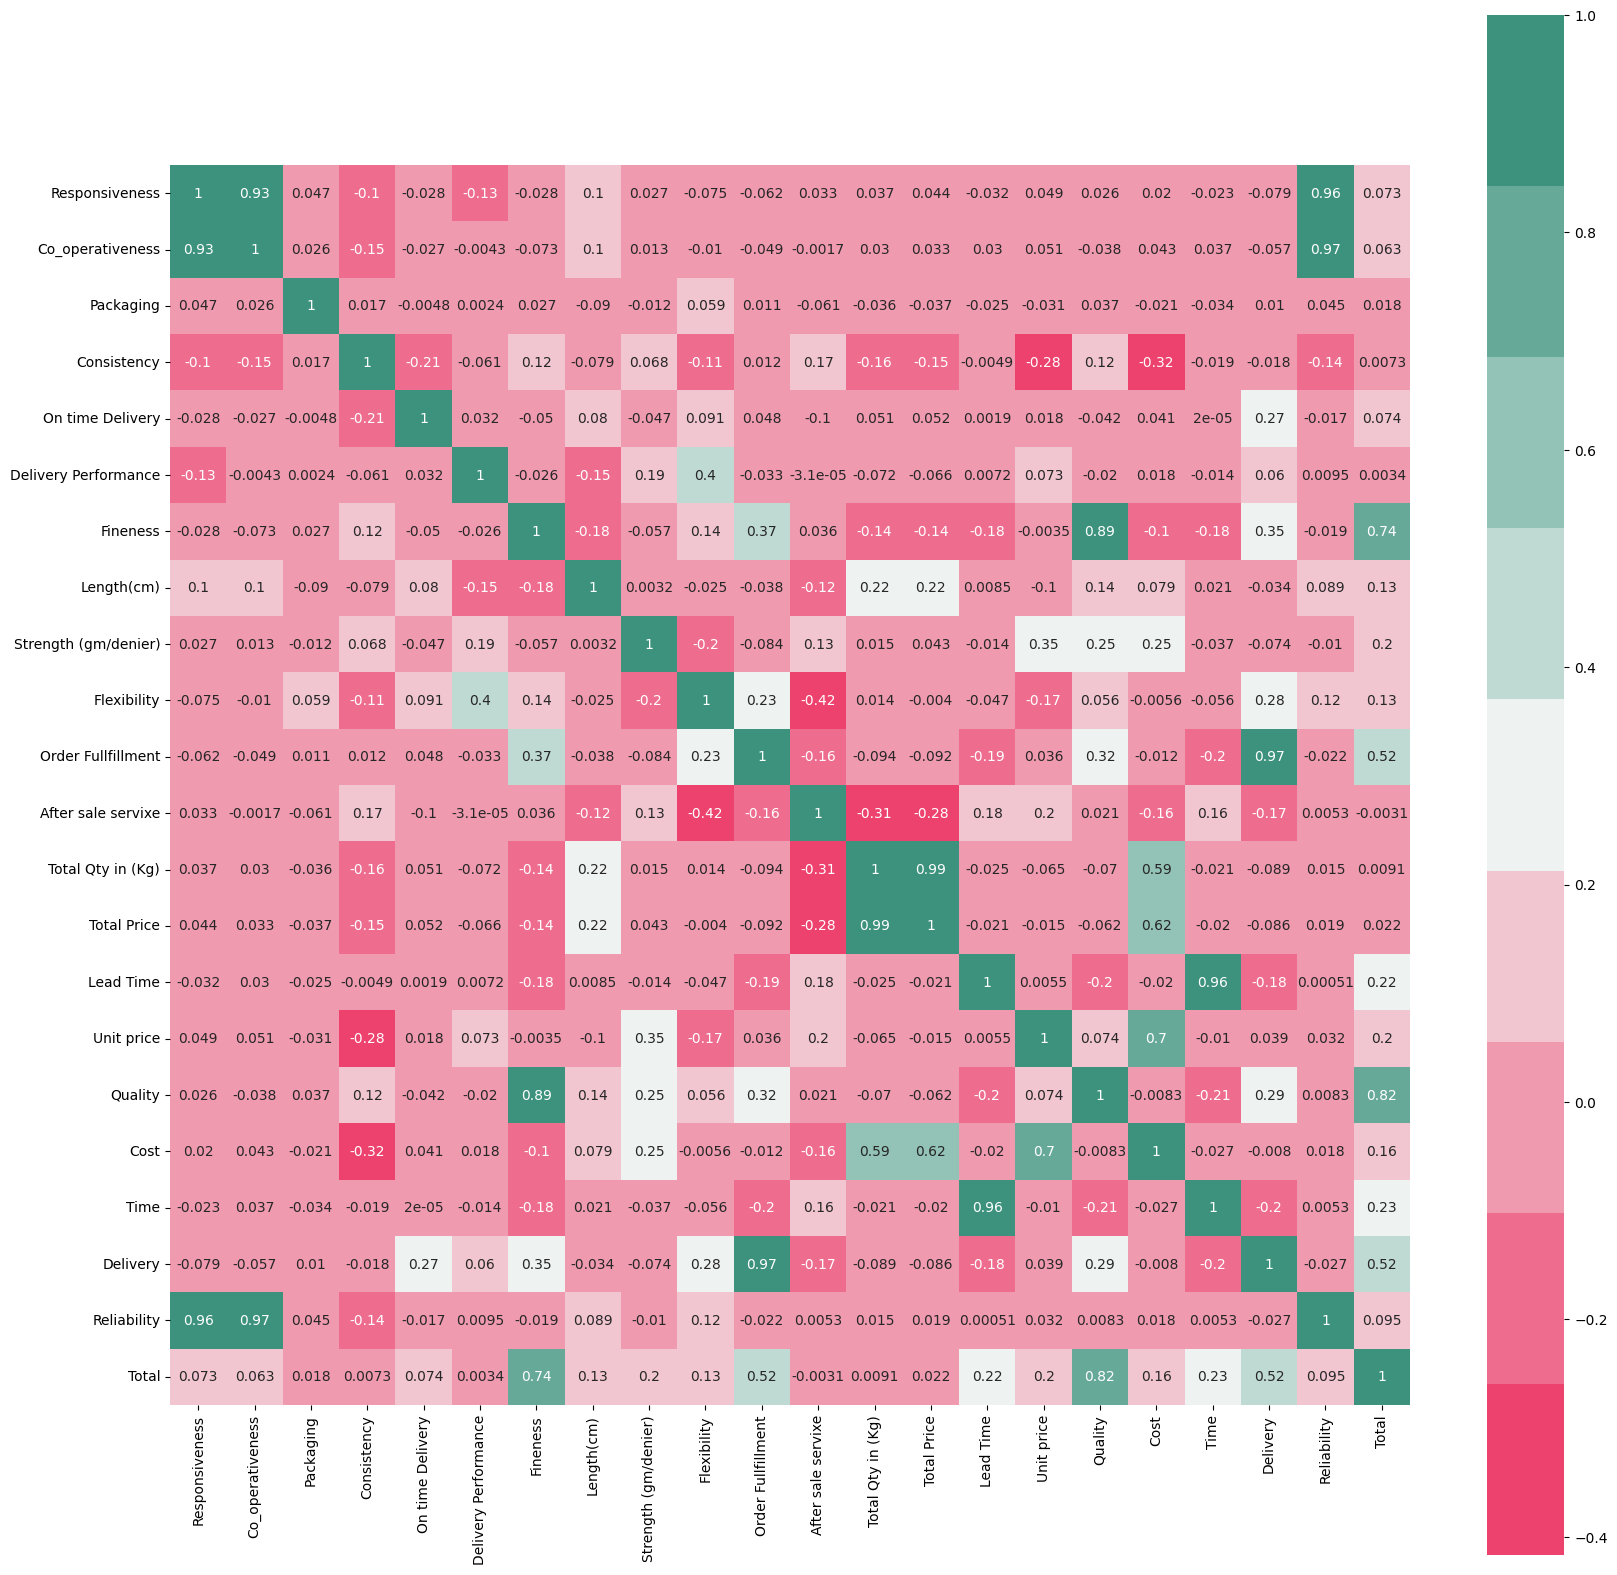

In [57]:
cmap = sns.diverging_palette(2, 165, s=80, l=55, n=9)
m_filtered_data=filtered_data.drop(columns=['Item Name', 'EWO No', 'Order Date','Delivery Date','Supplier Address'])
corrmat = m_filtered_data.corr()
plt.subplots(figsize=(20,20))
sns.heatmap(corrmat,cmap= cmap,annot=True, square=True)

In [84]:
X = m_filtered_data[['Quality', 'Delivery', 'Cost', 'Time', 'Total']]
y = m_filtered_data['Vendor']

In [85]:
col_names = list(X.columns)
s_scaler = preprocessing.StandardScaler()
X_scaled= s_scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=col_names)   
X_scaled.describe().T

,count,mean,std,min,25%,50%,75%,max
Quality,6785.0,-2.450508e-16,1.000074,-3.579150,-0.666329,0.337711,0.616770,1.710690
Delivery,6785.0,3.644346e-16,1.000074,-2.212842,-0.972334,0.651754,0.959274,1.061780
Cost,6785.0,-1.499627e-15,1.000074,-3.391668,-0.199012,-0.199012,-0.199012,12.571608
Time,6785.0,1.675561e-17,1.000074,-1.521376,-0.368278,-0.368278,-0.368278,4.244116
Total,6785.0,4.901017e-16,1.000074,-3.667655,-0.703177,0.116245,0.692342,3.529848


In [86]:
X_train, X_test, y_train,y_test = train_test_split(X_scaled,y,test_size=0.25,random_state=25)

In [87]:
# Instantiating the SVM algorithm 
model1=svm.SVC(C=10, degree=3)


# Fitting the model 
model1.fit (X_train, y_train)

# Predicting the test variables
y_pred = model1.predict(X_test)

# Getting the score 
model1.score (X_test, y_test)

0.5957572186210961

In [81]:
# Instantiating the Random Forest Classifier
model2 = RandomForestClassifier(n_estimators=100, random_state=42)  # You can adjust parameters like n_estimators, max_depth, etc.

# Fitting the model
model2.fit(X_train, y_train)
model2.score(X_test,y_test)

0.9534472598703595